In [81]:
import h3
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import contextily as cx
import seaborn as sns
import shapely

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.cluster import HDBSCAN

In [82]:
df_tracks = gpd.read_parquet("../data/cleaned/track_info.parquet")
df_tracks['start_point'].iloc[0].coords[0]

(-88.321538, 41.911011)

In [83]:
class TrackCellTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, cell_res=11):
        self.cell_res = cell_res

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.iloc[:, 0].apply(
                lambda track: " ".join(
                    h3.latlng_to_cell(lat, lon, res=self.cell_res)
                    for line in track.geoms
                    for lat, lon in line.coords
                )
            )
    
class PointCellTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, cell_res=11):
        self.cell_res = cell_res

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.iloc[:, 0].apply(lambda point: h3.latlng_to_cell(point.coords[0][0], point.coords[0][1], res=self.cell_res)).to_frame()


In [ ]:
track_cells_pipeline = Pipeline(
    steps=[
        ('h3', TrackCellTransformer(cell_res=12)),
        ('vectorizor', TfidfVectorizer()),
    ]
)

# start_cell_pipeline = Pipeline(
#     steps=[
#         ('h3', PointCellTransformer(cell_res=7)),
#         ('encoder', OneHotEncoder()),
#         ('weight', FunctionTransformer((lambda x: 5*x))),
#     ]
# )

# num_pipeline = Pipeline(
#     steps=[
#         ('scaler', StandardScaler())
#     ]
# )

preprocessor = ColumnTransformer(
    transformers=[
        ('track_line_cells', track_cells_pipeline, ["track_line"]),
        # ('start_point_cell', start_cell_pipeline, ["start_point"]),
        # ("numeric", num_pipeline, ["total_distance (mi)", "total_elevation_change (m)"]),
    ],
    remainder='drop'
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('estimator', HDBSCAN(metric='cosine', min_cluster_size=4)),
    ]
)

In [85]:
_ = model.fit(df_tracks)

/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [86]:
df_tracks['route_label'] = model.named_steps['estimator'].labels_
df_tracks['route_probability'] = model.named_steps['estimator'].probabilities_
df_tracks

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line,route_label,route_probability
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,Freshman,Summer Training,0 days 00:48:28,3.063156,8.542777,77.126862,True,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215...",-1,0.000000
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,Freshman,Summer Training,0 days 00:33:20,3.172008,8.767494,122.178753,True,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ...",31,1.000000
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,2019-06-12 11:53:30+00:00,2019-06-12 12:35:13+00:00,Freshman,Summer Training,0 days 00:41:43,3.052702,8.581829,132.038013,True,POINT (-88.32152 41.91252),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32152 41.91252, -88.3215...",20,0.463217
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,Freshman,Summer Training,0 days 00:30:00,2.983042,9.088904,86.000490,True,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ...",-1,0.000000
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,Freshman,Summer Training,0 days 00:25:23,2.355063,9.380388,95.971917,True,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541...",30,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00-05:00,2023-05-04,2023-05-04 19:54:31+00:00,2023-05-04 20:10:21+00:00,Senior,Track Season,0 days 00:15:50,2.032107,7.547855,23.622665,True,POINT (-88.27989 41.92867),POINT (-88.27976 41.92838),"MULTILINESTRING ((-88.27989 41.92867, -88.2798...",51,1.000000
1029,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00-05:00,2023-05-04,2023-05-04 20:24:15+00:00,2023-05-04 20:42:07+00:00,Senior,Track Season,0 days 00:17:52,0.999846,5.064146,8.642043,True,POINT (-88.27658 41.92845),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27658 41.92845, -88.2765...",62,0.660102
1030,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00-05:00,2023-05-05,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,Senior,Track Season,0 days 00:26:52,3.509378,6.976707,43.772437,True,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798...",45,0.681107
1031,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00-05:00,2023-05-06,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,Senior,Track Season,0 days 00:16:34,1.985944,7.678578,38.987511,True,POINT (-88.32198 41.95005),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219...",12,0.554839


* multipage_plots_0: resolution 12 with numeric parameters
    * OK, but missing some routes
* multipage_plots_1: resolution 12 without numeric parameters
    * Markedly better
* multipage_plots_2: resolution 12 without numeric parameters, with start point cell resolution 6
    * Markedly worse than both

In [87]:
df_tracks['route_label'].value_counts()

route_label
-1     220
 8     110
 46     61
 62     50
 45     47
      ... 
 26      4
 15      4
 14      4
 61      4
 6       4
Name: count, Length: 67, dtype: int64

12.318181818181818 7.0
N Clusters: 67


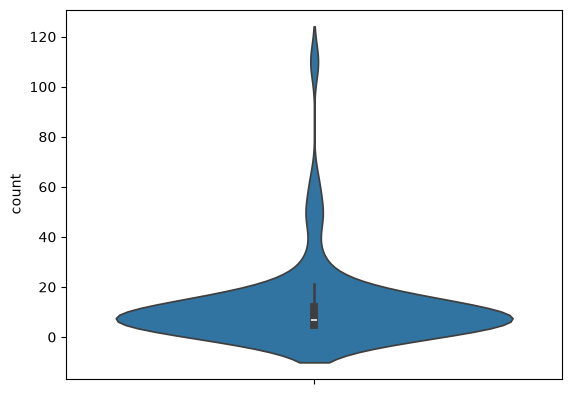

In [88]:
sns.violinplot(df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts())
print(df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().mean(), df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().median())
print("N Clusters:",len(df_tracks['route_label'].value_counts()))

In [89]:
with PdfPages('multipage_plots.pdf') as pdf:

    ### TITLE PAGE
    page_num = 1
    num_groups = len(df_tracks['route_label'].value_counts())
    num_runs_without_group = len(df_tracks.loc[df_tracks['route_label'] == -1])

    fig_cover = plt.figure(figsize=(8.5, 11))
    plt.axis('off')
    
    # Add centered text using Figure coordinates (0,0 is bottom-left, 1,1 is top-right)
    plt.text(0.025, 0.97, page_num, transform=fig_cover.transFigure)
    plt.text(0.5, 0.6, 'Unsupervised Route Clustering Results', transform=fig_cover.transFigure, size=24, ha='center', weight='bold')
    plt.text(0.5, 0.5, 'Generated automatically via Matplotlib', transform=fig_cover.transFigure, size=14, ha='center', style='italic')
    plt.text(0.5, 0.45, f'Number of Clusters: {num_groups}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.5, 0.4, f'Unclustered Routes: {num_runs_without_group}', transform=fig_cover.transFigure, size=10, ha='center')
    
    pdf.savefig(fig_cover)
    plt.close(fig_cover)
    page_num += 1


    ### TABLE OF CONTENTS
    fig_toc = plt.figure(figsize=(8.5, 11))
    plt.axis('off')
    toc_items = np.cumsum(df_tracks.loc[df_tracks['route_label'] != -1]['route_label'].value_counts().sort_index()  // 6 + 2) + 1
    for i, (route_id, page_num) in enumerate(list(zip(toc_items.index, toc_items.values))):
        plt.text(0.4, 0.95-i*0.018, f"Page {page_num} Cluster {route_id}", transform=fig_toc.transFigure, size=9)
    pdf.savefig(fig_toc)
    plt.close(fig_toc)
    page_num  = 3


    ### BODY
    for i, (name, group) in enumerate(df_tracks.groupby("route_label")):
        if name == -1:
            continue

        fig, ax = plt.subplots(figsize=(8.5, 11))
        group.to_crs(3857).plot("route_probability", ax=ax, legend=True)
        cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)
        ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        fig.text(0.025, 0.97, page_num)
        fig.text(0.025, 0.93, f"N={len(group)}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.91, f"Mean:{group['route_probability'].mean():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.89, f"Median:{group['route_probability'].median():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.87, f"Min:{group['route_probability'].min():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.35, 0.95, f"Cluster {name}", transform=fig.transFigure, fontsize=28, fontweight='bold')
        page_num += 1
        pdf.savefig(fig)
        plt.close(fig)

        # make a new page every 6 routes in the group
        run_num = 0
        row = 0
        col = 0
        for j in range((len(group) // 6) + 1*(len(group) % 6) != 0):
            fig, ax = plt.subplots(3, 2, figsize=(8.5, 11))
            for k in range(min(len(group) - (j*6), 6)):
                group[run_num:run_num+1].to_crs(3857).plot(ax=ax[row, col])
                cx.add_basemap(ax[row, col], source=cx.providers.CartoDB.Voyager)
                # ax[row, col].set_title(group[run_num:run_num+1].iloc[0]['track_file_datetime'])
                ax[row, col].text(0.2, 1.1, group[run_num:run_num+1].iloc[0]['track_file_datetime'], transform=ax[row, col].transAxes)
                ax[row, col].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
                if row < 2:
                    row += 1
                else:
                    row = 0
                    col += 1
                run_num += 1
            col = 0
            row = 0
            fig.text(0.01, 0.97, page_num)
            page_num += 1
            pdf.savefig(fig)
            plt.close(fig)

/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)
/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)
